In [6]:
import sys
print(sys.version)

3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


In [7]:
import pandas as pd

In [8]:
df = pd.read_csv("Amazon Sale Report.csv")
df.head()

C:\Users\tanus\AppData\Local\Temp\ipykernel_21092\3949281228.py:1: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Amazon Sale Report.csv")


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [9]:
print("Shape: ", df.shape)   #no.of rows and columns

print("\nColumns:")   #column names
print(df.columns)

print("\nData Types:")   #data types
print(df.dtypes)

print("\nData Information:")   #Basic information
df.info()

Shape:  (128975, 24)

Columns:
Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

Data Types:
index                   int64
Order ID               object
Date                   object
Status                 object
Fulfilment             object
Sales Channel          object
ship-service-level     object
Style                  object
SKU                    object
Category               object
Size                   object
ASIN                   object
Courier Status         object
Qty                     int64
currency               object
Amount                float64
ship-city              object
ship-state             object
ship-postal-code      float64
ship-country           obj

In [10]:
print("\nData Information:")   #Basic information
df.info()


Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount         

In [11]:
#Checking missing values

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_data = pd.DataFrame({"Missing Values": df.isnull().sum(),"Percentage": missing_percentage})
print(missing_data)

#Check duplicates

print("Duplicate rows:", df.duplicated().sum())   #count duplicate rows
print(df[df.duplicated()])   #display duplicate rows

#Check unique values

print("Order Status:")
print(df["Status"].value_counts())

print("\nCategories:")
print(df["Category"].value_counts())

print("\nFulfilment:")
print(df["Fulfilment"].value_counts())

print("\nSales Channel:")
print(df["Sales Channel "].value_counts())

print("\nSize:")
print(df["Size"].value_counts())

#Check numerical columns

print(df[["Qty", "Amount"]].describe())

#Check the date column

print(df["Date"].head())
print(df["Date"].dtype)

                    Missing Values  Percentage
index                            0    0.000000
Order ID                         0    0.000000
Date                             0    0.000000
Status                           0    0.000000
Fulfilment                       0    0.000000
Sales Channel                    0    0.000000
ship-service-level               0    0.000000
Style                            0    0.000000
SKU                              0    0.000000
Category                         0    0.000000
Size                             0    0.000000
ASIN                             0    0.000000
Courier Status                6872    5.328164
Qty                              0    0.000000
currency                      7795    6.043807
Amount                        7795    6.043807
ship-city                       33    0.025586
ship-state                      33    0.025586
ship-postal-code                33    0.025586
ship-country                    33    0.025586
promotion-ids

In [12]:
#Data cleaning

df.drop(columns=["index", "Unnamed: 22"], inplace=True)   #remove unnecessary columns
print(df.shape)

df.columns = df.columns.str.strip()   #Remove leading/trailing spaces from column names
print(df.columns)

df["Date"] = pd.to_datetime(df["Date"], format="%m-%d-%y")   #Convert Date to datetime
print(df["Date"].dtype)

print(df["Date"].min())
print(df["Date"].max())

print(df[df["Amount"].isnull()]["Status"].value_counts())   #Investigate Amount missing values

print(df.groupby("Status")["Amount"].apply(lambda x: x.isnull().sum()))

print(df["currency"].value_counts(dropna=False))   #Investigate Currency

print(df[df["ship-city"].isnull()])   #Investigate shipping information

print(pd.crosstab(df["Fulfilment"],df["fulfilled-by"],dropna=False))

print(pd.crosstab(df["Status"],df["Courier Status"],dropna=False))

#Check suspicious values

print("Orders with Qty = 0:")
print((df["Qty"] == 0).sum())

print(df[df["Qty"] == 0]["Status"].value_counts())

print("Rows with Amount = 0:")
print((df["Amount"] == 0).sum())

print(df[df["Amount"] == 0]["Status"].value_counts())

#Check categorical inconsistencies

print("Fulfilment:")
print(df["Fulfilment"].unique())

print("\nCategory:")
print(df["Category"].unique())

print("\nB2B:")
print(df["B2B"].value_counts())

print("\nCourier Status:")
print(df["Courier Status"].value_counts(dropna=False))

(128975, 22)
Index(['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by'],
      dtype='object')
datetime64[ns]
2022-03-31 00:00:00
2022-06-29 00:00:00
Status
Cancelled                       7566
Shipped                          208
Shipped - Delivered to Buyer       8
Shipping                           8
Shipped - Returned to Seller       3
Pending                            2
Name: count, dtype: int64
Status
Cancelled                        7566
Pending                             2
Pending - Waiting for Pick Up       0
Shipped                           208
Shipped - Damaged                   0
Shipped - Delivered to Buyer        8
Shipped - Lost in Transit           0
Shipped - Out for Delivery          0
Shipped - Picked Up            

In [13]:
#Cleaned Dataset

import pandas as pd

df = pd.read_csv("Amazon Sale Report.csv")   #load raw dataset

df.drop(columns=["index","Unnamed: 22"],inplace=True)  #remove unnecessary

df.columns = df.columns.str.strip()   #Clean Date to datetime

df["Date"] = pd.to_datetime(df["Date"], format="%m-%d-%y")   #Convert Date to datetime

df.dropna(subset=["ship-city","ship-state","ship-postal-code","ship-country"],inplace=True)   #Remove rows with missing shipping location

#check final dataset

print("Final Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

df["Month"] = df["Date"].dt.month   #month
df["Month_Name"] = df["Date"].dt.month_name()   #month name
df["Year"] = df["Date"].dt.year
df["Day"] = df["Date"].dt.day_name()

df["Promotion_Used"] = df["promotion-ids"].notna()   #promotion used


C:\Users\tanus\AppData\Local\Temp\ipykernel_21092\670325206.py:5: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Amazon Sale Report.csv")   #load raw dataset


Final Shape: (128942, 22)

Missing values:
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6869
Qty                       0
currency               7793
Amount                 7793
ship-city                 0
ship-state                0
ship-postal-code          0
ship-country              0
promotion-ids         49145
B2B                       0
fulfilled-by          89678
dtype: int64

Data types:
Order ID                      object
Date                  datetime64[ns]
Status                        object
Fulfilment                    object
Sales Channel                 object
ship-service-level            object
Style                         object
SKU                           object
Category           

In [14]:
df.to_csv("cleaned_amazon_sales.csv", index=False)
print("Cleaned Dataset saved successfully!")

Cleaned Dataset saved successfully!


In [15]:
df.shape

(128942, 27)

In [16]:
df.columns

Index(['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Month', 'Month_Name', 'Year', 'Day',
       'Promotion_Used'],
      dtype='object')

In [17]:
df.describe()

,Date,Qty,Amount,ship-postal-code,Month,Year
count,128942,128942.000000,121149.000000,128942.000000,128942.000000,128942.0
mean,2022-05-12 11:50:53.223930112,0.904445,648.573305,463966.236509,4.909207,2022.0
min,2022-03-31 00:00:00,0.000000,0.000000,110001.000000,3.000000,2022.0
25%,2022-04-20 00:00:00,1.000000,449.000000,382421.000000,4.000000,2022.0
50%,2022-05-10 00:00:00,1.000000,605.000000,500033.000000,5.000000,2022.0
75%,2022-06-04 00:00:00,1.000000,788.000000,600024.000000,6.000000,2022.0
max,2022-06-29 00:00:00,15.000000,5584.000000,989898.000000,6.000000,2022.0
std,NaN,0.313340,281.222115,191476.764941,0.818410,0.0


In [18]:
df["Status"].value_counts()

Status
Shipped                          77788
Shipped - Delivered to Buyer     28762
Cancelled                        18325
Shipped - Returned to Seller      1950
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

In [19]:
df["Fulfilment"].value_counts()

Fulfilment
Amazon      89678
Merchant    39264
Name: count, dtype: int64

In [20]:
df["Sales Channel"].value_counts()

Sales Channel
Amazon.in     128818
Non-Amazon       124
Name: count, dtype: int64

In [21]:
df["Category"].value_counts()

Category
Set              50272
kurta            49859
Western Dress    15499
Top              10620
Ethnic Dress      1159
Blouse             926
Bottom             440
Saree              164
Dupatta              3
Name: count, dtype: int64

In [22]:
category_sales = (
    df.groupby("Category")["Amount"].sum().sort_values(ascending=False)
)
category_sales

Category
Set              39195176.03
kurta            21291538.70
Western Dress    11215337.69
Top               5346812.30
Ethnic Dress       791217.66
Blouse             458408.18
Bottom             150667.98
Saree              123933.76
Dupatta               915.00
Name: Amount, dtype: float64

In [23]:
category_qty = (
    df.groupby("Category")["Qty"]
      .sum()
      .sort_values(ascending=False)
)

category_qty

Category
Set              45278
kurta            45031
Western Dress    13942
Top               9901
Ethnic Dress      1053
Blouse             863
Bottom             398
Saree              152
Dupatta              3
Name: Qty, dtype: int64

In [24]:
category_avg = (
    df.groupby("Category")
      .agg(
          Total_Quantity=("Qty", "sum"),
          Total_Sales=("Amount", "sum"),
          Average_Amount=("Amount", "mean")
      )
      .sort_values("Total_Sales", ascending=False)
)

category_avg

,Total_Quantity,Total_Sales,Average_Amount
Category,,,
Set,45278,39195176.03,833.390233
kurta,45031,21291538.70,455.921600
Western Dress,13942,11215337.69,762.792470
Top,9901,5346812.30,526.105707
Ethnic Dress,1053,791217.66,723.895389
Blouse,863,458408.18,520.327106
Bottom,398,150667.98,358.733286
Saree,152,123933.76,799.572645
Dupatta,3,915.00,305.000000


In [25]:
monthly_sales = (
    df.groupby("Month_Name")["Amount"]
      .sum()
)
monthly_sales

Month_Name
April    28831249.32
June     23421223.38
March      101683.85
May      26219850.75
Name: Amount, dtype: float64

In [26]:
monthly_qty = (
    df.groupby("Month_Name")["Qty"]
      .sum()
)

monthly_qty

Month_Name
April    44196
June     34269
March      156
May      38000
Name: Qty, dtype: int64

In [27]:
status_sales = (
    df.groupby("Status")["Amount"]
      .sum()
      .sort_values(ascending=False)
)
status_sales

Status
Shipped                          50314279.0
Shipped - Delivered to Buyer     18645779.0
Cancelled                         6917254.3
Shipped - Returned to Seller      1268015.0
Shipped - Picked Up                661252.0
Pending                            430271.0
Pending - Waiting for Pick Up      192138.0
Shipped - Returning to Seller      107620.0
Shipped - Out for Delivery          26971.0
Shipped - Rejected by Buyer          7295.0
Shipped - Lost in Transit            1997.0
Shipped - Damaged                    1136.0
Shipping                                0.0
Name: Amount, dtype: float64

In [28]:
cancelled_count = (df["Status"] == "Cancelled").sum()
total_orders = len(df)

cancellation_rate = (cancelled_count / total_orders) * 100

print("Cancelled Orders:", cancelled_count)
print("Total Records:", total_orders)
print("Cancellation Rate:", round(cancellation_rate, 2), "%")

Cancelled Orders: 18325
Total Records: 128942
Cancellation Rate: 14.21 %


In [29]:
total_records = len(df)
unique_orders = df["Order ID"].nunique()

print("Total Records:", total_records)
print("Unique Orders:", unique_orders)
print("Duplicate Order IDs:", total_records - unique_orders)

Total Records: 128942
Unique Orders: 120350
Duplicate Order IDs: 8592


In [30]:
order_counts = df["Order ID"].value_counts()

order_counts.head(10)

Order ID
403-4984515-8861958    12
171-5057375-2831560    12
403-0173977-3041148    11
404-9932919-6662730    11
408-3317403-1729937    10
406-9002076-4152331     9
408-2964501-8373155     9
171-0706521-2133101     9
404-3701762-8241125     9
171-4310662-2005103     9
Name: count, dtype: int64

In [31]:
order_counts.value_counts().sort_index()

count
1     113508
2       5652
3        858
4        218
5         68
6         16
7         13
8          7
9          5
10         1
11         2
12         2
Name: count, dtype: int64

In [32]:
order_status = (
    df.groupby("Order ID")["Status"]
      .agg(lambda x: "Cancelled" if (x == "Cancelled").all() else "Not Cancelled")
)

order_cancellation_rate = (
    (order_status == "Cancelled").sum()
    / len(order_status)
) * 100

print("Unique Orders:", len(order_status))
print("Cancelled Orders:", (order_status == "Cancelled").sum())
print("Order Cancellation Rate:", round(order_cancellation_rate, 2), "%")

Unique Orders: 120350
Cancelled Orders: 17179
Order Cancellation Rate: 14.27 %


In [33]:
order_summary = (
    df.groupby("Order ID")
      .agg(
          Total_Amount=("Amount", "sum"),
          Total_Quantity=("Qty", "sum"),
          Status=("Status", "first")
      )
)

order_summary.head()


print("Total Unique Orders:", len(order_summary))
print("Total Recorded Sales:", order_summary["Total_Amount"].sum())
print("Average Order Value:", order_summary["Total_Amount"].mean())

Total Unique Orders: 120350
Total Recorded Sales: 78574007.3
Average Order Value: 652.8791632737848


In [34]:
def classify_order_status(statuses):
    statuses = set(statuses)

    if statuses == {"Cancelled"}:
        return "Cancelled"
    elif any("Delivered" in s for s in statuses):
        return "Delivered"
    elif any("Returned" in s or "Returning" in s for s in statuses):
        return "Returned"
    elif any("Shipped" in s for s in statuses):
        return "Shipped"
    elif any("Pending" in s or s == "Shipping" for s in statuses):
        return "Pending"
    else:
        return "Other"


order_status = df.groupby("Order ID")["Status"].apply(classify_order_status)

order_status.value_counts()

Status
Shipped      73780
Delivered    26559
Cancelled    17179
Returned      1978
Pending        854
Name: count, dtype: int64

In [35]:
state_sales = (
    df.groupby("ship-state")["Amount"]
      .sum()
      .sort_values(ascending=False)
)

state_sales.head(10)

ship-state
MAHARASHTRA       13335534.14
KARNATAKA         10481114.37
TELANGANA          6916615.65
UTTAR PRADESH      6816642.08
TAMIL NADU         6515650.11
DELHI              4235215.97
KERALA             3830227.58
WEST BENGAL        3507880.44
ANDHRA PRADESH     3219831.72
HARYANA            2882092.99
Name: Amount, dtype: float64

In [36]:
state_qty = (
    df.groupby("ship-state")["Qty"]
      .sum()
      .sort_values(ascending=False)
)

state_qty.head(10)

ship-state
MAHARASHTRA       20328
KARNATAKA         15901
TAMIL NADU        10412
TELANGANA         10253
UTTAR PRADESH      9499
DELHI              6156
KERALA             5813
WEST BENGAL        5318
ANDHRA PRADESH     4819
Gujarat            4149
Name: Qty, dtype: int64

In [37]:
state_avg_amount = (
    df.groupby("ship-state")["Amount"]
      .mean()
      .sort_values(ascending=False)
)

state_avg_amount.head(10)

ship-state
bihar          1432.000000
LADAKH          914.010238
Sikkim          901.000000
delhi           827.681000
Chandigarh      823.147273
NAGALAND        801.288659
LAKSHADWEEP     793.822500
SIKKIM          738.639893
Mizoram         735.000000
Punjab          733.766667
Name: Amount, dtype: float64

In [38]:
state_records = (
    df.groupby("ship-state")
      .size()
      .sort_values(ascending=False)
)

state_records.head(15)

ship-state
MAHARASHTRA       22260
KARNATAKA         17326
TAMIL NADU        11483
TELANGANA         11330
UTTAR PRADESH     10638
DELHI              6782
KERALA             6585
WEST BENGAL        5963
ANDHRA PRADESH     5430
Gujarat            4489
HARYANA            4415
RAJASTHAN          2650
MADHYA PRADESH     2529
ODISHA             2115
BIHAR              2086
dtype: int64

In [39]:
df["ship-state"] = df["ship-state"].str.strip().str.upper()

state_records = (
    df.groupby("ship-state")
      .size()
      .sort_values(ascending=False)
)

state_records.head(15)

ship-state
MAHARASHTRA       22260
KARNATAKA         17326
TAMIL NADU        11483
TELANGANA         11330
UTTAR PRADESH     10638
DELHI              6967
KERALA             6585
WEST BENGAL        5963
ANDHRA PRADESH     5430
GUJARAT            4489
HARYANA            4415
RAJASTHAN          2711
MADHYA PRADESH     2529
ODISHA             2136
BIHAR              2114
dtype: int64

In [40]:
df.to_csv("cleaned_amazon_sales.csv", index=False)
print("Updated cleaned data saved successfully!")

Updated cleaned data saved successfully!


In [41]:
daily_sales = (
    df.groupby("Date")["Amount"]
      .sum()
      .sort_values(ascending=False)
)

daily_sales.head(10)

Date
2022-05-04    1208509.17
2022-05-03    1190672.59
2022-05-02    1172327.06
2022-04-14    1113487.56
2022-04-23    1092882.62
2022-04-20    1091550.41
2022-04-24    1082483.95
2022-05-01    1079957.52
2022-04-10    1075234.03
2022-04-15    1024143.13
Name: Amount, dtype: float64

In [42]:
daily_sales = (
    df.groupby("Date")["Amount"]
      .sum()
      .sort_index()
)

daily_sales.head(10)

Date
2022-03-31     101683.85
2022-04-01     865478.60
2022-04-02     913101.53
2022-04-03    1011763.38
2022-04-04     882059.17
2022-04-05     950544.05
2022-04-06     886985.26
2022-04-07     909899.35
2022-04-08    1017857.61
2022-04-09     972076.48
Name: Amount, dtype: float64

In [43]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
import matplotlib.pyplot as plt

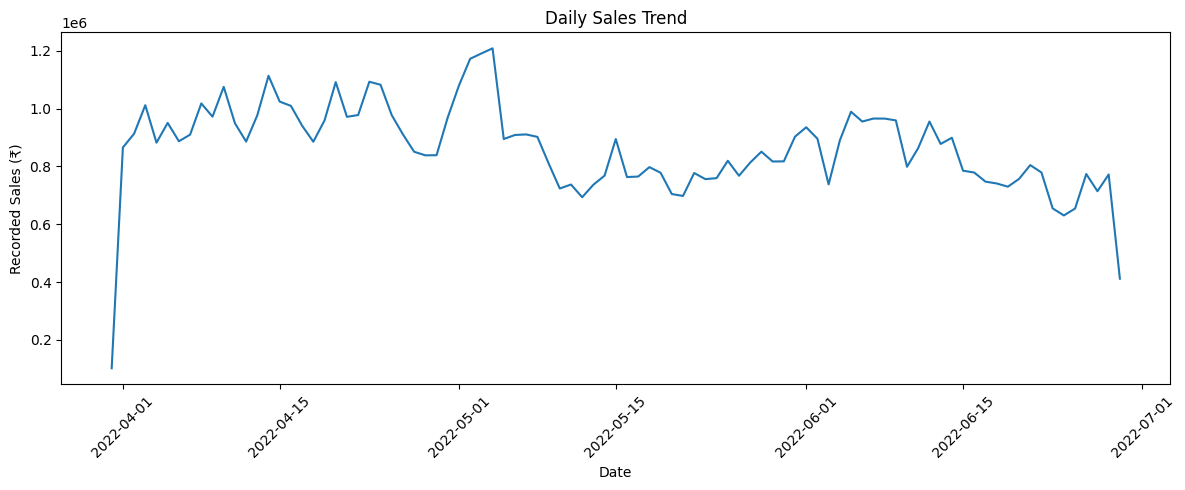

In [45]:
plt.figure(figsize=(12, 5))

plt.plot(daily_sales.index, daily_sales.values)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Recorded Sales (₹)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [46]:
monthly_sales = (
    df.groupby(["Year", "Month_Name"])["Amount"]
      .sum()
)

monthly_sales

Year  Month_Name
2022  April         28831249.32
      June          23421223.38
      March           101683.85
      May           26219850.75
Name: Amount, dtype: float64

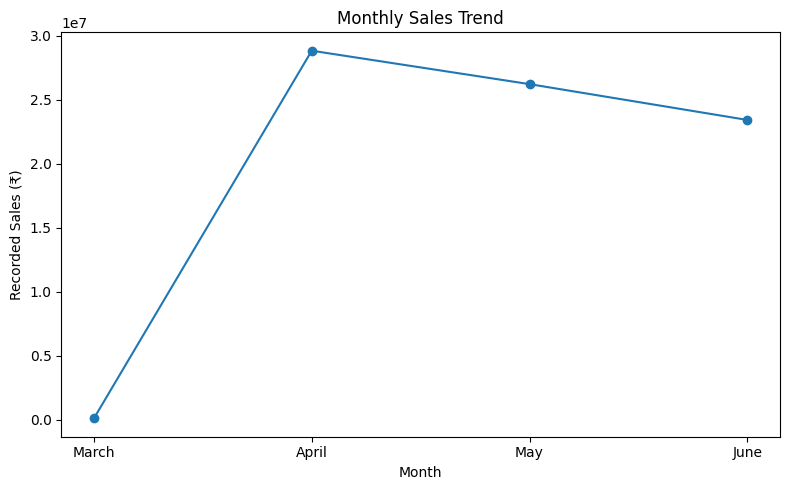

In [47]:
import matplotlib.pyplot as plt

monthly_sales = (
    df.groupby("Month_Name")["Amount"]
      .sum()
)

month_order = ["March", "April", "May", "June"]

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(8, 5))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Recorded Sales (₹)")
plt.tight_layout()

plt.show()

In [48]:
status_count = df["Status"].value_counts()
status_count

Status
Shipped                          77788
Shipped - Delivered to Buyer     28762
Cancelled                        18325
Shipped - Returned to Seller      1950
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

In [49]:
def simplify_status(status):
    if status == "Cancelled":
        return "Cancelled"
    elif "Returned" in status or "Returning" in status:
        return "Returned"
    elif "Delivered" in status:
        return "Delivered"
    elif "Shipped" in status or status in ["Shipping"]:
        return "Shipped"
    elif "Pending" in status:
        return "Pending"
    else:
        return "Other"

df["Status_Group"] = df["Status"].apply(simplify_status)

df["Status_Group"].value_counts()

Status_Group
Shipped      78821
Delivered    28762
Cancelled    18325
Returned      2095
Pending        939
Name: count, dtype: int64

In [50]:
df.to_csv("cleaned_amazon_sales.csv", index=False)
print("Cleaned dataset updated successfully!")

Cleaned dataset updated successfully!


In [51]:
promotion_count = df["Promotion_Used"].value_counts()

promotion_count

Promotion_Used
True     79797
False    49145
Name: count, dtype: int64

In [52]:
promotion_sales = (
    df.groupby("Promotion_Used")["Amount"]
      .sum()
)

promotion_sales

Promotion_Used
False    25001294.3
True     53572713.0
Name: Amount, dtype: float64

In [53]:
promotion_avg = (
    df.groupby("Promotion_Used")["Amount"]
      .mean()
)

promotion_avg

Promotion_Used
False    599.680850
True     674.226799
Name: Amount, dtype: float64

In [54]:
b2b_analysis = (
    df.groupby("B2B")
      .agg(
          Records=("Order ID", "count"),
          Total_Amount=("Amount", "sum"),
          Average_Amount=("Amount", "mean"),
          Total_Quantity=("Qty", "sum")
      )
)

b2b_analysis

,Records,Total_Amount,Average_Amount,Total_Quantity
B2B,,,,
False,128071,77982786.51,648.203635,115781
True,871,591220.79,701.329526,840


In [55]:
fulfilment_analysis = (
    df.groupby("Fulfilment")
      .agg(
          Records=("Order ID", "count"),
          Total_Amount=("Amount", "sum"),
          Average_Amount=("Amount", "mean"),
          Total_Quantity=("Qty", "sum")
      )
)

fulfilment_analysis

,Records,Total_Amount,Average_Amount,Total_Quantity
Fulfilment,,,,
Amazon,89678,54311285.0,649.493369,84069
Merchant,39264,24262722.3,646.523191,32552
